# Task 5:
 1.Train a Decision Tree Classifier and visualize the tree.

 2.Analyze overfitting and control tree depth.

 3.Train a Random Forest and compare accuracy.

 4.Interpret feature importances.

 5.Evaluate using cross-validation

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score

# Data Loading

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
print("Shape of the DataFrame:", df.shape)

Shape of the DataFrame: (1025, 14)


In [4]:
display(df.head())
display(df.info())
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: >

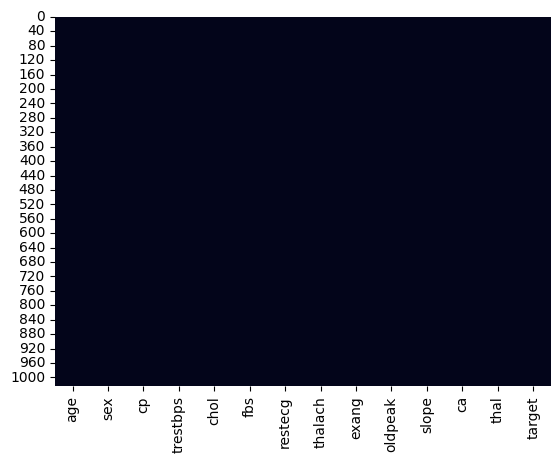

In [5]:
sns.heatmap(df.isnull(), cbar=False)

In [6]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Number of duplicate rows: 723


In [7]:
df.drop_duplicates(inplace=True)
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


# Data Visualization


Target Variable Distribution:
 target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


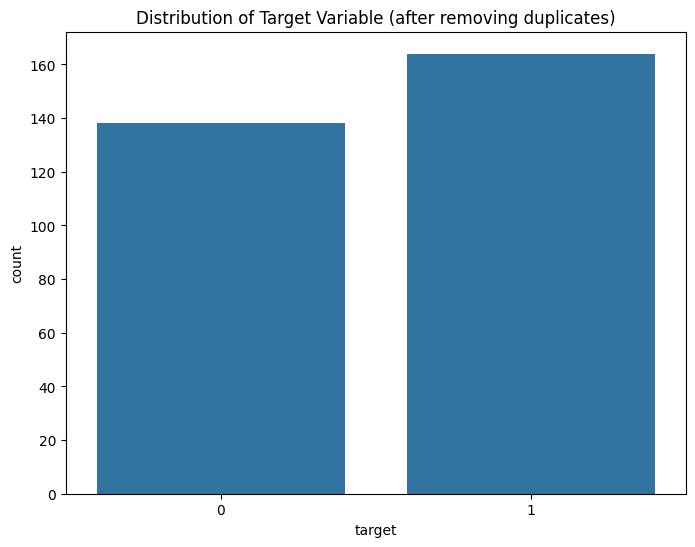

In [8]:
print("\nTarget Variable Distribution:\n", df['target'].value_counts(normalize=True) * 100)
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable (after removing duplicates)')
plt.show()

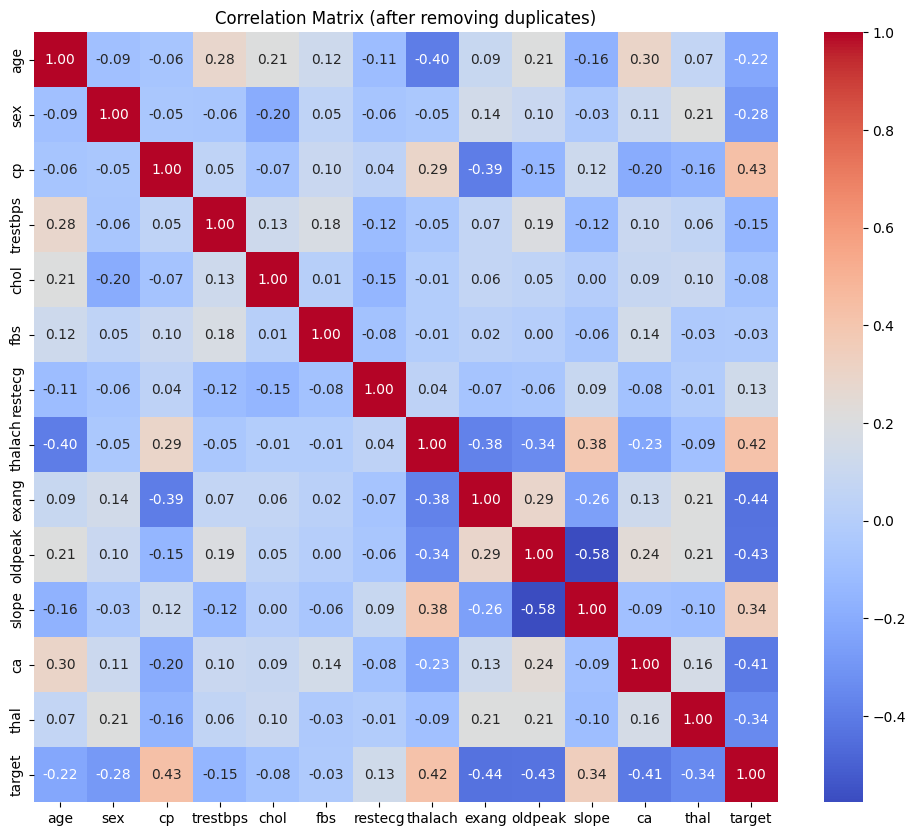

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (after removing duplicates)')
plt.show()

# Data Preparation

In [10]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (226, 13)
X_test shape: (76, 13)
y_train shape: (226,)
y_test shape: (76,)


# Model Training

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Visualizing the trained Decision Tree

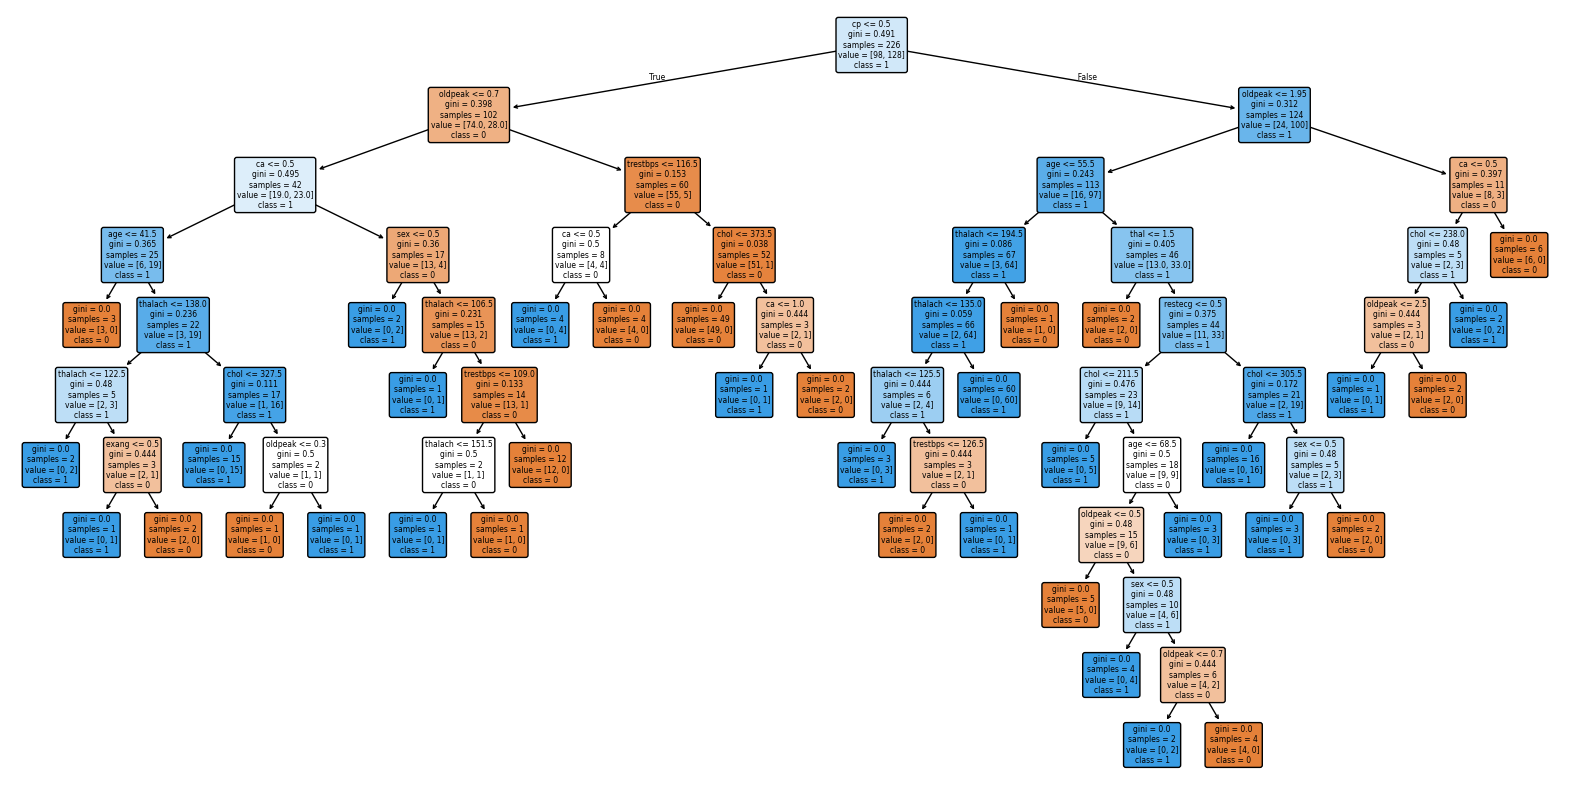

In [12]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X_train.columns, class_names=['0', '1'], rounded=True)
plt.show()

In [13]:
y_pred_dt = dt_model.predict(X_test)

# Model Evaluation

In [14]:
print("Decision Tree Performance on Test Set:")
print("Accuracy             :", accuracy_score(y_test, y_pred_dt))
print("Precision            :", precision_score(y_test, y_pred_dt))
print("Recall               :", recall_score(y_test, y_pred_dt))
print("F1-score             :", f1_score(y_test, y_pred_dt))
print("Confusion Matri      :\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Performance on Test Set:
Accuracy             : 0.75
Precision            : 0.7428571428571429
Recall               : 0.7222222222222222
F1-score             : 0.7323943661971831
Confusion Matri      :
 [[31  9]
 [10 26]]


# Model Optimization

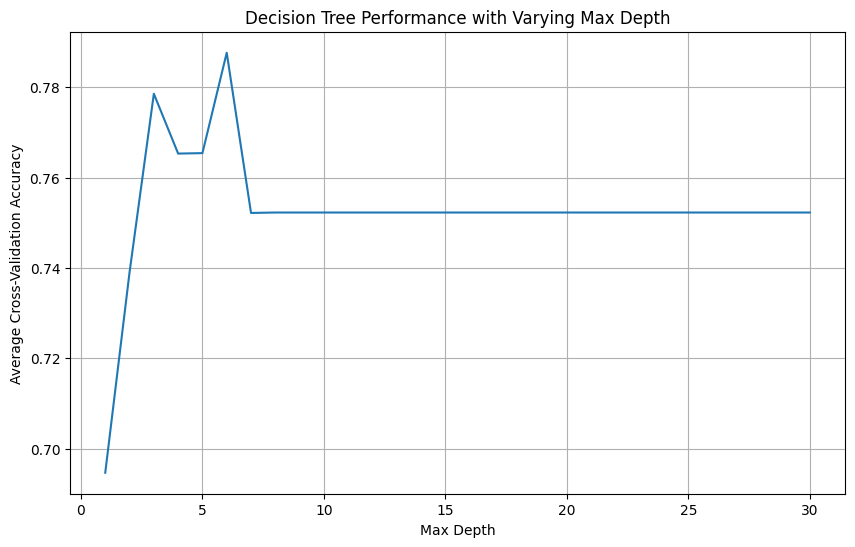

The optimal max_depth is: 6


In [15]:
max_depths = list(range(1, 31))
cv_scores = []

for max_depth in max_depths:
    dt_model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    scores = cross_val_score(dt_model, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(max_depths, cv_scores)
plt.xlabel("Max Depth")
plt.ylabel("Average Cross-Validation Accuracy")
plt.title("Decision Tree Performance with Varying Max Depth")
plt.grid(True)
plt.show()

best_depth = max_depths[cv_scores.index(max(cv_scores))]
print(f"The optimal max_depth is: {best_depth}")

# Model Training

In [16]:
rf_model = RandomForestClassifier(max_depth = 6, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)

# Model Evalution

In [18]:
print("Random Forest Performance on Test Set:")
print("Accuracy         :", accuracy_score(y_test, y_pred_rf))
print("Precision        :", precision_score(y_test, y_pred_rf))
print("Recall           :", recall_score(y_test, y_pred_rf))
print("F1-score         :", f1_score(y_test, y_pred_rf))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Performance on Test Set:
Accuracy         : 0.7894736842105263
Precision        : 0.7380952380952381
Recall           : 0.8611111111111112
F1-score         : 0.7948717948717948
Confusion Matrix :
 [[29 11]
 [ 5 31]]


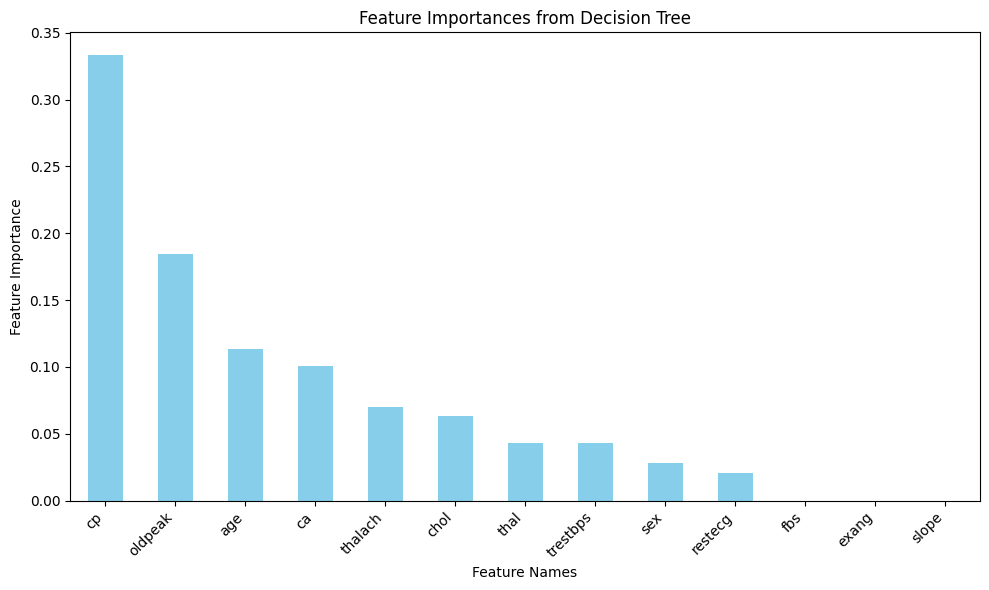


Summary of Top 3 Important Features:
- cp: 0.3336
- oldpeak: 0.1846
- age: 0.1133


In [19]:
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_model.fit(X_train, y_train)

feature_importances = dt_model.feature_importances_

feature_imp_series = pd.Series(feature_importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_imp_series.plot(kind='bar', color='skyblue')
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance")
plt.title("Feature Importances from Decision Tree")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_3_features = feature_imp_series.head(3)
print("\nSummary of Top 3 Important Features:")
for feature, importance in top_3_features.items():
    print(f"- {feature}: {importance:.4f}")

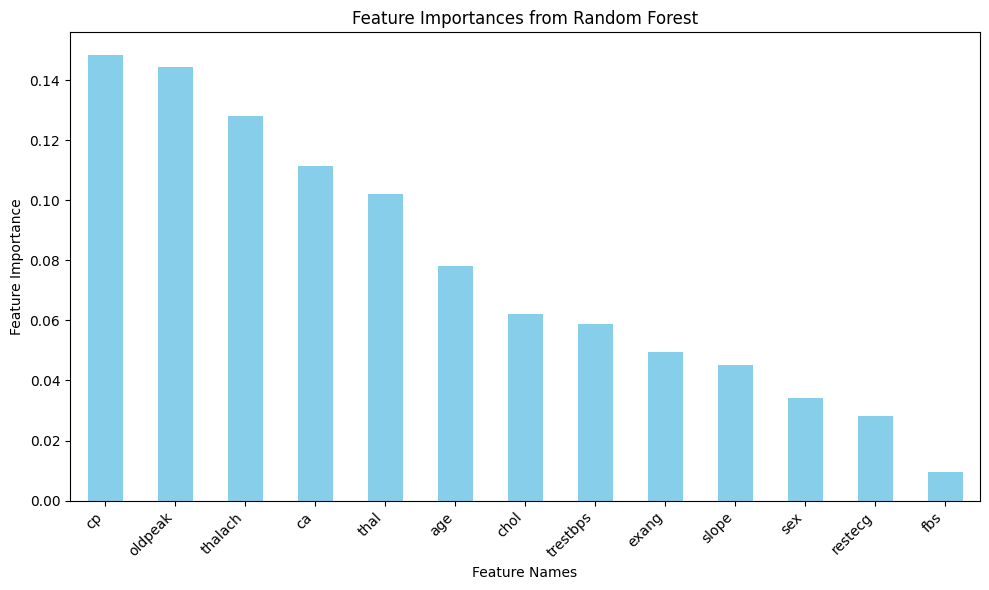


Summary of Top 3 Important Features:
- cp: 0.1486
- oldpeak: 0.1444
- thalach: 0.1280


In [20]:
feature_importances = rf_model.feature_importances_

feature_imp_series = pd.Series(feature_importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_imp_series.plot(kind='bar', color='skyblue')
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance")
plt.title("Feature Importances from Random Forest")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_3_features = feature_imp_series.head(3)
print("\nSummary of Top 3 Important Features:")
for feature, importance in top_3_features.items():
    print(f"- {feature}: {importance:.4f}")

# Evaluating using cross-Validation

In [21]:
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5)
mean_dt_cv_accuracy = dt_cv_scores.mean()

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
mean_rf_cv_accuracy = rf_cv_scores.mean()

print(f"Decision Tree mean cross-validation accuracy: {mean_dt_cv_accuracy}")
print(f"Random Forest mean cross-validation accuracy: {mean_rf_cv_accuracy}")

Decision Tree mean cross-validation accuracy: 0.7876328502415461
Random Forest mean cross-validation accuracy: 0.8231884057971015


In [22]:
if mean_dt_cv_accuracy > mean_rf_cv_accuracy:
    print("Decision Tree appears to generalize better based on cross-validation.")
elif mean_rf_cv_accuracy > mean_dt_cv_accuracy:
    print("Random Forest appears to generalize better based on cross-validation.")
else:
    print("Both models have similar generalization performance based on cross-validation.")

Random Forest appears to generalize better based on cross-validation.
